# Chile Mineral Supply Chain: Data Pipeline and Network Analysis

This notebook runs the complete workflow for analysing Chile's mine-to-processing-plant supply chain. It is split into two parts:

**Part A (Sections 0-8): Data pipeline.** Downloads facility data from Sernageomin's ArcGIS service, loads USGS mineral processing facilities and HS92 trade data, harmonises commodity names, deduplicates across sources, infers mine-to-plant links by commodity and proximity, and cross-references with export statistics.

**Part B (Sections 9-22): Network analysis and visualisation.** Constructs a bipartite network from the inferred links, computes centrality metrics, detects communities (Louvain), builds unipartite projections, analyses commodity subnetworks, and produces static plots, an interactive D3 force-directed graph, and an interactive Folium geographic map.

**Inputs:**
- ArcGIS FeatureServer (Sernageomin, downloaded live)
- `MINFAC_LAC.csv` (USGS, local)
- `Chile_HS92_Exports_6digit.csv` (Harvard Growth Lab, local)

**Outputs (organised into subdirectories):**

| Folder | Contents |
|---|---|
| `Outputs/` | Static PNGs (network plot, centrality, communities, commodity comparison, projections, supply chain map) |
| `Interactive/` | HTML files (D3 force-directed network, Folium geographic map) |
| `Preliminary/` | `Chile_Minerals_Inventory.csv`, `Chile_Minerals_Inventory.geojson`, `Chile_Mine_Plant_Links.csv`, `Chile_Supply_Chain_Summary.csv`, `Chile_Network_Metrics.csv`, `Chile_Network_Summary.txt` |

## 0. Setup

In [5]:
import os, json, time, warnings, requests
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree
import networkx as nx
from networkx.algorithms import bipartite

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec

import folium

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 9,
    "axes.titlesize": 11, "axes.labelsize": 9,
    "figure.facecolor": "white", "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#cccccc", "grid.color": "#e0e0e0", "grid.linewidth": 0.5,
})

# Paths
BASE_DIR = "/Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile"
USGS_PATH = "/Users/leoss/Downloads/MINFAC_LAC.csv"
HS92_PATH = os.path.join(BASE_DIR, "Chile_HS92_Exports_6digit.csv")
LINKS_PATH = os.path.join(BASE_DIR, "Chile_Mine_Plant_Links.csv")
INVENTORY_PATH = os.path.join(BASE_DIR, "Chile_Minerals_Inventory.csv")

DIR_OUT    = os.path.join(BASE_DIR, "Outputs")
DIR_HTML   = os.path.join(BASE_DIR, "Interactive")
DIR_PRELIM = os.path.join(BASE_DIR, "Preliminary")
for d in [DIR_OUT, DIR_HTML, DIR_PRELIM]:
    os.makedirs(d, exist_ok=True)

# ArcGIS endpoint
BASE_URL = "https://services1.arcgis.com/OyjvVdFTl5hfSdX3/arcgis/rest/services/EMC_F/FeatureServer"

# Chile bounding box (mainland)
CHILE_LAT_MIN, CHILE_LAT_MAX = -56.0, -17.5
CHILE_LON_MIN, CHILE_LON_MAX = -76.0, -66.0

LINK_MAX_KM = 150  # max mine-plant distance

# Commodity colour palette
COMMODITY_COLORS = {
    "Copper": "#d63031", "Gold": "#fdcb6e", "Silver": "#636e72",
    "Iron": "#e17055", "Molybdenum": "#6c5ce7", "Iodine": "#00b894",
    "Nitrate": "#00cec9", "Rhenium": "#a29bfe", "Manganese": "#e84393",
    "Zinc": "#74b9ff", "Boron": "#55efc4", "Lithium": "#fd79a8",
}
DEFAULT_COLOR = "#b2bec3"

def commodity_color(c):
    return COMMODITY_COLORS.get(c, DEFAULT_COLOR)

start_time = time.time()

## 1. Commodity harmonisation and helper functions

Spanish-to-English mappings for Sernageomin data, plus USGS naming inconsistencies. Helper functions for ArcGIS download, haversine distance, facility classification, and commodity parsing.

In [6]:
# Spanish -> English and USGS inconsistencies
COMMODITY_MAP = {
    "Cobre": "Copper", "Oro": "Gold", "Plata": "Silver",
    "Hierro": "Iron", "Litio": "Lithium", "Nitrato": "Nitrate",
    "Boro": "Boron", "Cinc": "Zinc", "Manganeso": "Manganese",
    "Titanio": "Titanium", "Tierras raras": "Rare Earths",
    "Molibdeno": "Molybdenum", "Cobalto": "Cobalt", "Renio": "Rhenium",
    "Potasio": "Potassium", "Yodo": "Iodine", "Selenio": "Selenium",
    "Telurio": "Tellurium", "Antimonio": "Antimony",
    "Nitrates": "Nitrate", "Iron and steel": "Iron",
    "Sulfuric acid": "Sulfuric Acid", "Calcium carbonate": "Calcium Carbonate",
    "Phosphatic materials": "Phosphate", "Sodium sulfate": "Sodium Sulfate",
    "Potassium chloride": "Potassium", "Natural gas": "Natural Gas",
}

def harmonize_commodity(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    return COMMODITY_MAP.get(name, name)

def parse_commodity_list(combo_string):
    if pd.isna(combo_string):
        return []
    parts = str(combo_string).replace(",", "-").replace("/", "-").split("-")
    return [harmonize_commodity(p.strip()) for p in parts if p.strip()]

def classify_usgs_plant(name):
    name = str(name).lower()
    for kw, label in [("smelter", "Smelter"), ("refin", "Refinery"),
                       ("sx-ew", "SX-EW Plant"), ("sx/ew", "SX-EW Plant"),
                       ("concentrat", "Concentrator"), ("flotation", "Concentrator"),
                       ("milling", "Concentrator"), ("pellet", "Pellet Plant"),
                       ("grinding", "Grinding Plant"), ("steel", "Steel Plant")]:
        if kw in name:
            return label
    return "Processing Plant"

USGS_STATUS_MAP = {"A": "Active", "C": "Closed", "S": "Standby", "CM": "Care & Maintenance"}

FACILITY_STAGE = {
    "Mine (active)": "extraction", "Mine (idle)": "extraction",
    "Prospect/Project": "extraction", "Mine (USGS)": "extraction",
    "Concentrator": "processing", "SX-EW Plant": "processing",
    "Smelter": "processing", "Refinery": "processing",
    "Processing Plant": "processing", "Pellet Plant": "processing",
    "Grinding Plant": "processing", "Steel Plant": "processing",
}

def download_layer(layer_id, with_geometry=True):
    all_features, offset = [], 0
    while True:
        params = {"where": "1=1", "outFields": "*", "f": "json",
                  "resultRecordCount": 2000, "resultOffset": offset}
        if with_geometry:
            params.update({"outSR": "4326", "returnGeometry": "true"})
        r = requests.get(f"{BASE_URL}/{layer_id}/query", params=params, timeout=60)
        r.raise_for_status()
        features = r.json().get("features", [])
        if not features:
            break
        all_features.extend(features)
        if len(features) < 2000:
            break
        offset += len(features)
    return all_features

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

## 2. Download Sernageomin critical minerals

Downloads deposit and reserve/resource records from Sernageomin's ArcGIS FeatureServer. Reserve data is pivoted so each deposit has one row with resource and reserve columns per commodity.

In [7]:
dep_features = download_layer(0, with_geometry=True)
res_features = download_layer(3, with_geometry=False)
print(f"Deposits: {len(dep_features)}, Reserve/resource records: {len(res_features)}")

rows = []
for feat in dep_features:
    row = feat.get("attributes", {})
    geom = feat.get("geometry")
    if geom and "x" in geom:
        row["geometry"] = Point(geom["x"], geom["y"])
        row["LATITUD"] = geom["y"]
        row["LONGITUD"] = geom["x"]
    else:
        row["geometry"] = None
    rows.append(row)
serna_gdf = gpd.GeoDataFrame(pd.DataFrame(rows), geometry="geometry", crs="EPSG:4326")

# Pivot reserves
reservas = pd.DataFrame([f["attributes"] for f in res_features])
if len(reservas) > 0:
    rp = reservas.pivot_table(index="ID_DEPOSITO", columns=["MINERAL", "TIPO"],
                              values="VALOR", aggfunc="sum")
    rp.columns = [f"{m}_{t}" for m, t in rp.columns]
    rp = rp.reset_index()
    serna_gdf = serna_gdf.merge(rp, left_on="ID", right_on="ID_DEPOSITO", how="left")
    serna_gdf.drop(columns=["ID_DEPOSITO"], errors="ignore", inplace=True)

# Standardise columns
serna_gdf["SOURCE"] = "Sernageomin_2025"
serna_gdf["STATUS"] = serna_gdf["ESTADO_DEPOSITO"].map({
    "Mina en producci\u00f3n": "Active", "Mina paralizada": "Idle",
    "Mina Paralizada": "Idle", "Prospecto/Proyecto": "Prospect/Project"})
serna_gdf["FACILITY_TYPE"] = serna_gdf["ESTADO_DEPOSITO"].map({
    "Mina en producci\u00f3n": "Mine (active)", "Mina paralizada": "Mine (idle)",
    "Mina Paralizada": "Mine (idle)", "Prospecto/Proyecto": "Prospect/Project"})
serna_gdf["FACILITY_NAME"] = serna_gdf["NOMBRE_DEPOSITO"]
serna_gdf["PRIMARY_COMMODITY"] = serna_gdf["CRITICO_1"].apply(harmonize_commodity)
serna_gdf["ALL_COMMODITIES_RAW"] = serna_gdf["COMBINACION_CRITICO"]
for col in ["OPERATOR_NAME", "OWNER_NAME", "CAPACITY", "CAPACITY_UNITS"]:
    serna_gdf[col] = None

# Rename reserve columns to English
rename = {}
for col in serna_gdf.columns:
    new = col
    for es, en in COMMODITY_MAP.items():
        if es in new:
            new = new.replace(es, en)
    new = new.replace("_Recurso", "_Resource").replace("_Reserva", "_Reserve")
    if new != col:
        rename[col] = new
serna_gdf.rename(columns=rename, inplace=True)

print(f"Sernageomin: {serna_gdf.shape}")

Deposits: 267, Reserve/resource records: 365
Sernageomin: (267, 65)


## 3. Load USGS mineral facilities

Loads processing plants and mine records from the USGS MINFAC_LAC dataset. Plants are kept as network nodes; mine records provide ownership data for Sernageomin enrichment.

In [8]:
usgs = pd.read_csv(USGS_PATH, encoding="latin-1")
chile_usgs = usgs[usgs["COUNTRY"].str.strip().str.lower() == "chile"].copy()

plants = chile_usgs[chile_usgs["FACTYPE"].isin(["P", "B", "OR", "MP", "p"])].copy()
plants["FACILITY_TYPE"] = plants["LOCNAME"].apply(classify_usgs_plant)

usgs_mines = chile_usgs[chile_usgs["FACTYPE"].isin(["M", "m", "DM", "SM"])].copy()
usgs_mines["FACILITY_TYPE"] = "Mine (USGS)"

plants["geometry"] = plants.apply(
    lambda r: Point(r["DDLONG"], r["DDLAT"])
    if pd.notna(r["DDLAT"]) and pd.notna(r["DDLONG"]) else None, axis=1)
plants_gdf = gpd.GeoDataFrame(plants, geometry="geometry", crs="EPSG:4326")

plants_gdf["SOURCE"] = "USGS_MINFAC_2017"
plants_gdf["FACILITY_NAME"] = plants_gdf["LOCNAME"]
plants_gdf["PRIMARY_COMMODITY"] = plants_gdf["COMMODITY"].apply(harmonize_commodity)
plants_gdf["ALL_COMMODITIES_RAW"] = plants_gdf["COMMODITY"]
plants_gdf["OPERATOR_NAME"] = plants_gdf["OPERATOR"]
plants_gdf["OWNER_NAME"] = plants_gdf["OWNER"]
plants_gdf["CAPACITY"] = plants_gdf["ANNCAP"]
plants_gdf["CAPACITY_UNITS"] = plants_gdf["UNITS"]
plants_gdf["LATITUD"] = plants_gdf["DDLAT"]
plants_gdf["LONGITUD"] = plants_gdf["DDLONG"]
plants_gdf["REGION"] = plants_gdf["ADM1"]
plants_gdf["STATUS"] = plants_gdf["STATUS"].map(USGS_STATUS_MAP).fillna(plants_gdf["STATUS"])

usgs_mines_df = usgs_mines[["LOCNAME", "COMMODITY", "OPERATOR", "OWNER", "DDLAT", "DDLONG"]].copy()
usgs_mines_df["LOCNAME_lower"] = usgs_mines_df["LOCNAME"].str.lower().str.strip()

print(f"USGS Chile: {len(chile_usgs)} total, {len(plants)} plants, {len(usgs_mines)} mines")

USGS Chile: 394 total, 194 plants, 192 mines


## 4. Merge and deduplicate

Combines Sernageomin and USGS records into a single inventory. Where a Sernageomin mine matches a USGS mine record by name prefix and commodity, ownership data is transferred. Exact duplicates (same name, same commodity, both extraction-stage) are dropped from the USGS side.

In [9]:
all_cols = list(set(serna_gdf.columns) | set(plants_gdf.columns))
for col in all_cols:
    if col not in serna_gdf.columns:
        serna_gdf[col] = None
    if col not in plants_gdf.columns:
        plants_gdf[col] = None

combined = gpd.GeoDataFrame(
    pd.concat([serna_gdf[all_cols], plants_gdf[all_cols]], ignore_index=True), crs="EPSG:4326")
print(f"Before dedup: {len(combined)}")

# Enrich Sernageomin ownership from USGS mine records
serna_mask = combined["SOURCE"] == "Sernageomin_2025"
serna_rows = combined[serna_mask].copy()
serna_rows["name_lower"] = serna_rows["FACILITY_NAME"].str.lower().str.strip()

enriched = 0
for idx, row in serna_rows.iterrows():
    matches = usgs_mines_df[usgs_mines_df["LOCNAME_lower"].str.contains(
        row["name_lower"][:8], case=False, na=False, regex=False)]
    if len(matches) > 0:
        best = matches.iloc[0]
        if pd.isna(combined.at[idx, "OPERATOR_NAME"]) and pd.notna(best["OPERATOR"]):
            combined.at[idx, "OPERATOR_NAME"] = best["OPERATOR"]
            enriched += 1
        if pd.isna(combined.at[idx, "OWNER_NAME"]) and pd.notna(best["OWNER"]):
            combined.at[idx, "OWNER_NAME"] = best["OWNER"]
print(f"Enriched {enriched} records with USGS ownership")

# Drop USGS duplicates of Sernageomin extraction records
combined["_name_lower"] = combined["FACILITY_NAME"].str.lower().str.strip()
combined["_stage"] = combined["FACILITY_TYPE"].map(FACILITY_STAGE)
usgs_mask = combined["SOURCE"] == "USGS_MINFAC_2017"

dupes = []
for _, srow in combined[serna_mask & (combined["_stage"] == "extraction")].iterrows():
    pot = combined[usgs_mask & (combined["_name_lower"] == srow["_name_lower"])
                   & (combined["PRIMARY_COMMODITY"] == srow["PRIMARY_COMMODITY"])]
    dupes.extend(pot.index.tolist())
dupes = list(set(dupes))
if dupes:
    combined.drop(index=dupes, inplace=True)
    print(f"Dropped {len(dupes)} USGS duplicates")

combined.drop(columns=["_name_lower", "_stage"], errors="ignore", inplace=True)
combined.reset_index(drop=True, inplace=True)
print(f"After dedup: {len(combined)}")

Before dedup: 461
Enriched 62 records with USGS ownership
After dedup: 461


## 5. Parse secondary commodities

Parses multi-commodity strings (e.g. "Copper-Molybdenum-Rhenium") into lists, creating an exploded view for commodity-level lookups used in mine-plant linking.

In [10]:
combined["COMMODITY_LIST"] = combined["ALL_COMMODITIES_RAW"].apply(parse_commodity_list)
combined["N_COMMODITIES"] = combined["COMMODITY_LIST"].apply(len)

multi = combined[combined["N_COMMODITIES"] > 1]
print(f"Multi-commodity facilities: {len(multi)}, max per facility: {combined['N_COMMODITIES'].max()}")

exploded = combined.explode("COMMODITY_LIST").reset_index(drop=True)
exploded = exploded.drop(columns=["COMMODITY"], errors="ignore")
exploded = exploded.rename(columns={"COMMODITY_LIST": "COMMODITY"})
exploded = exploded[exploded["COMMODITY"].notna() & (exploded["COMMODITY"].astype(str) != "")].reset_index(drop=True)

commodity_counts = exploded.groupby("COMMODITY")["FACILITY_NAME"].count().sort_values(ascending=False)
print(f"Unique commodities: {len(commodity_counts)}")
print(commodity_counts.head(15).to_string())

Multi-commodity facilities: 142, max per facility: 4
Unique commodities: 44
COMMODITY
Copper               193
Gold                 103
Silver                63
Molybdenum            44
Iron                  26
Nitrate               21
Iodine                21
Boron                 20
Calcium Carbonate     16
Cobalt                16
Lithium               15
Zinc                  14
Rhenium               14
Silica                10
Potassium              9


## 6. Geographic consistency checks

Flags any records falling outside Chile's mainland bounding box or near the Argentine border.

In [11]:
has_coords = combined[combined["LATITUD"].notna() & combined["LONGITUD"].notna()].copy()
print(f"Records with coordinates: {len(has_coords)} / {len(combined)}")

outside = has_coords[
    (has_coords["LONGITUD"] > CHILE_LON_MAX) | (has_coords["LONGITUD"] < CHILE_LON_MIN) |
    (has_coords["LATITUD"] > CHILE_LAT_MAX) | (has_coords["LATITUD"] < CHILE_LAT_MIN)]
if len(outside) > 0:
    print(f"{len(outside)} records OUTSIDE Chile bounding box:")
    print(outside[["FACILITY_NAME", "REGION", "LONGITUD", "LATITUD", "PRIMARY_COMMODITY", "SOURCE"]].to_string(index=False))
else:
    print("All records within Chile bounding box.")

border = has_coords[has_coords["LONGITUD"] > -67.5].sort_values("LONGITUD", ascending=False)
print(f"Border-zone records (lon > -67.5): {len(border)}")
if len(border) > 0:
    print(border[["FACILITY_NAME", "REGION", "LONGITUD", "LATITUD", "PRIMARY_COMMODITY"]].to_string(index=False))

Records with coordinates: 461 / 461
All records within Chile bounding box.
Border-zone records (lon > -67.5): 5
              FACILITY_NAME                               REGION   LONGITUD    LATITUD PRIMARY_COMMODITY
       Lavadero Isla Picton Magallanes y de la Antártica Chilena -66.950000 -55.033333              Gold
         Salar de Quisquiro                          Antofagasta -67.270000 -23.220000             Boron
Salar Aguas Calientes Norte                          Antofagasta -67.410000 -23.120000             Boron
                    El Laco                          Antofagasta -67.476667 -23.826667              Iron
El Laco concentration plant                          Antofagasta -67.485600 -23.843500              Iron


## 7. Link mines to processing facilities

For each mine, identifies all processing plants that handle at least one shared commodity within the distance threshold (150 km by default). Links are ranked by distance.

In [12]:
combined["_stage"] = combined["FACILITY_TYPE"].map(FACILITY_STAGE)

mines = combined[(combined["_stage"] == "extraction")
                 & combined["LATITUD"].notna() & combined["LONGITUD"].notna()].copy()
plants_link = combined[(combined["_stage"] == "processing")
                       & combined["LATITUD"].notna() & combined["LONGITUD"].notna()].copy()

print(f"Mines/prospects with coords: {len(mines)}")
print(f"Processing facilities with coords: {len(plants_link)}")

mine_comms = {idx: set(r.get("COMMODITY_LIST") or [r["PRIMARY_COMMODITY"]]) for idx, r in mines.iterrows()}
plant_comms = {idx: set(r.get("COMMODITY_LIST") or [r["PRIMARY_COMMODITY"]]) for idx, r in plants_link.iterrows()}

link_rows = []
for midx, mrow in mines.iterrows():
    mc = mine_comms[midx]
    if not mc:
        continue
    for pidx, prow in plants_link.iterrows():
        shared = mc & plant_comms[pidx]
        if not shared:
            continue
        dist = haversine_km(mrow["LATITUD"], mrow["LONGITUD"], prow["LATITUD"], prow["LONGITUD"])
        if dist <= LINK_MAX_KM:
            link_rows.append({
                "MINE_NAME": mrow["FACILITY_NAME"], "MINE_IDX": midx,
                "MINE_TYPE": mrow["FACILITY_TYPE"], "MINE_STATUS": mrow["STATUS"],
                "MINE_LAT": mrow["LATITUD"], "MINE_LON": mrow["LONGITUD"],
                "MINE_REGION": mrow.get("REGION"), "MINE_OPERATOR": mrow.get("OPERATOR_NAME"),
                "PLANT_NAME": prow["FACILITY_NAME"], "PLANT_IDX": pidx,
                "PLANT_TYPE": prow["FACILITY_TYPE"], "PLANT_STATUS": prow["STATUS"],
                "PLANT_LAT": prow["LATITUD"], "PLANT_LON": prow["LONGITUD"],
                "PLANT_OPERATOR": prow.get("OPERATOR_NAME"), "PLANT_OWNER": prow.get("OWNER_NAME"),
                "PLANT_CAPACITY": prow.get("CAPACITY"), "PLANT_CAPACITY_UNITS": prow.get("CAPACITY_UNITS"),
                "SHARED_COMMODITIES": ", ".join(sorted(shared)),
                "DISTANCE_KM": round(dist, 1),
            })

links_df = pd.DataFrame(link_rows)
if len(links_df) > 0:
    links_df.sort_values(["MINE_NAME", "DISTANCE_KM"], inplace=True)
    print(f"Links: {len(links_df)}, unique mines: {links_df['MINE_NAME'].nunique()}, "
          f"unique plants: {links_df['PLANT_NAME'].nunique()}")
    unlinked = mines[~mines.index.isin(set(links_df['MINE_IDX']))]
    print(f"Mines with no nearby processing: {len(unlinked)}")
    if len(unlinked) > 0:
        print(unlinked["PRIMARY_COMMODITY"].value_counts().to_string())
else:
    print("No links found within distance threshold.")

combined.drop(columns=["_stage"], errors="ignore", inplace=True)

Mines/prospects with coords: 267
Processing facilities with coords: 194
Links: 1370, unique mines: 206, unique plants: 78
Mines with no nearby processing: 60
PRIMARY_COMMODITY
Gold           20
Copper         11
Lithium         8
Boron           6
Titanium        4
Manganese       4
Rare Earths     3
Silver          2
Zinc            2


## 8. Trade data cross-reference and save pipeline outputs

Matches mineral commodities to HS92 6-digit product codes and computes export values. Determines whether each commodity has domestic extraction, processing, or both. Saves the full inventory, links, and summary to `Preliminary/`.

In [13]:
# HS92 commodity -> product code mapping
HS92_COMMODITY_MAP = {
    "Copper": {"260300": "Copper ores and concentrates", "740311": "Refined copper, cathodes",
               "740312": "Refined copper, wire bars", "740400": "Copper waste and scrap",
               "740319": "Refined copper, other", "740321": "Copper alloys, copper-zinc",
               "740329": "Copper alloys, other"},
    "Lithium": {"283691": "Lithium carbonate", "253090": "Lithium minerals (ores)"},
    "Molybdenum": {"261310": "Molybdenum ores, roasted", "261390": "Molybdenum ores, other",
                   "810294": "Molybdenum, unwrought"},
    "Gold": {"710812": "Gold, non-monetary, unwrought", "261690": "Precious metal ores"},
    "Silver": {"710691": "Silver, unwrought", "261610": "Silver ores and concentrates"},
    "Iron": {"260111": "Iron ores, non-agglomerated", "260112": "Iron ores, agglomerated",
             "720110": "Pig iron", "720241": "Ferrochromium"},
    "Nitrate": {"310239": "Sodium nitrate", "310250": "Sodium nitrate, natural", "283410": "Nitrites"},
    "Iodine": {"280120": "Iodine"},
    "Boron": {"252810": "Borates, natural", "281000": "Boric acid"},
    "Zinc": {"260800": "Zinc ores and concentrates", "790111": "Zinc, not alloyed, unwrought"},
    "Rhenium": {"811292": "Rhenium, unwrought"},
    "Potassium": {"310420": "Potassium chloride"},
    "Rare Earths": {"280530": "Rare earth metals"},
    "Selenium": {"280490": "Selenium"},
}

summary = None
if os.path.exists(HS92_PATH):
    trade = pd.read_csv(HS92_PATH)
    cols = trade.columns.tolist()
    product_col = "product_hs92_code"
    export_col = next((c for c in cols if "export" in c.lower()), None)
    year_col = next((c for c in cols if "year" in c.lower()), None)

    if all([product_col in cols, export_col, year_col]):
        trade[product_col] = trade[product_col].astype(str).str.zfill(6)
        latest_year = trade[year_col].max()
        print(f"Trade data: {trade.shape}, latest year: {latest_year}")

        summary_rows = []
        for commodity, hs_codes in HS92_COMMODITY_MAP.items():
            n_active = len(combined[(combined["FACILITY_TYPE"] == "Mine (active)")
                                    & combined["COMMODITY_LIST"].apply(lambda x: commodity in (x or []))])
            n_mines = len(combined[combined["FACILITY_TYPE"].isin(["Mine (active)", "Mine (idle)", "Prospect/Project"])
                                   & combined["COMMODITY_LIST"].apply(lambda x: commodity in (x or []))])
            n_plants = len(combined[(combined["FACILITY_TYPE"].map(FACILITY_STAGE) == "processing")
                                    & combined["COMMODITY_LIST"].apply(lambda x: commodity in (x or []))])
            n_links = len(links_df[links_df["SHARED_COMMODITIES"].str.contains(commodity, na=False)]) if len(links_df) else 0

            hs_list = list(hs_codes.keys())
            lt = trade[(trade[year_col] == latest_year) & (trade[product_col].isin(hs_list))]
            total_exp = lt[export_col].sum() if len(lt) else 0

            raw_codes = [c for c in hs_list if any(k in hs_codes[c].lower()
                         for k in ["ore", "concentrate", "mineral", "natural"])]
            proc_codes = [c for c in hs_list if c not in raw_codes]
            raw_exp = trade[(trade[year_col] == latest_year) & (trade[product_col].isin(raw_codes))][export_col].sum() if raw_codes else 0
            proc_exp = trade[(trade[year_col] == latest_year) & (trade[product_col].isin(proc_codes))][export_col].sum() if proc_codes else 0

            if n_active > 0 and n_plants > 0:
                status = "Extraction + Processing"
            elif n_active > 0:
                status = "Extraction only"
            elif n_plants > 0:
                status = "Processing only"
            else:
                status = "No active facilities"

            summary_rows.append({
                "COMMODITY": commodity, "ACTIVE_MINES": n_active,
                "TOTAL_MINES_PROSPECTS": n_mines, "PROCESSING_FACILITIES": n_plants,
                "MINE_PLANT_LINKS": n_links, "CHAIN_STATUS": status,
                f"EXPORT_TOTAL_{latest_year}_USD": total_exp,
                f"EXPORT_RAW_{latest_year}_USD": raw_exp,
                f"EXPORT_PROCESSED_{latest_year}_USD": proc_exp,
                "RAW_SHARE": round(raw_exp / total_exp, 3) if total_exp > 0 else None,
            })
        summary = pd.DataFrame(summary_rows).sort_values(f"EXPORT_TOTAL_{latest_year}_USD", ascending=False)
        print(summary.to_string(index=False))
    else:
        print(f"Could not detect columns. Available: {cols}")
else:
    print(f"HS92 file not found at {HS92_PATH}")

# --- Save pipeline outputs ---
drop_cols = ["_stage", "_name_lower", "COMMODITY_LIST"]
out = combined.drop(columns=[c for c in drop_cols if c in combined.columns], errors="ignore")
if "COMMODITY_LIST" in out.columns:
    out["COMMODITY_LIST"] = out["COMMODITY_LIST"].apply(lambda x: ", ".join(x) if isinstance(x, list) else x)

out.to_file(os.path.join(DIR_PRELIM, "Chile_Minerals_Inventory.geojson"), driver="GeoJSON")
pd.DataFrame(out.drop(columns="geometry")).to_csv(os.path.join(DIR_PRELIM, "Chile_Minerals_Inventory.csv"), index=False)

if len(links_df) > 0:
    links_df.to_csv(os.path.join(DIR_PRELIM, "Chile_Mine_Plant_Links.csv"), index=False)
if summary is not None:
    summary.to_csv(os.path.join(DIR_PRELIM, "Chile_Supply_Chain_Summary.csv"), index=False)

print(f"\nPipeline outputs saved to {DIR_PRELIM}")
print(f"  Inventory: {len(out)} records")
print(f"  Links: {len(links_df)}")

HS92 file not found at /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Chile_HS92_Exports_6digit.csv

Pipeline outputs saved to /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Preliminary
  Inventory: 461 records
  Links: 1370


---
# Part B: Network Analysis

The remaining sections construct a bipartite network from the mine-plant links produced above (or loaded from `Chile_Mine_Plant_Links.csv` if the pipeline was run previously), compute centrality and community structure, and generate visualisations.

## 9. Load link data for network analysis

If the pipeline ran above, `links_df` is already in memory. Otherwise, load from the CSV produced by a previous run.

In [14]:
# Use pipeline output if available, otherwise load from CSV
if 'links_df' not in dir() or len(links_df) == 0:
    links = pd.read_csv(os.path.join(DIR_PRELIM, "Chile_Mine_Plant_Links.csv"))
else:
    links = links_df.copy()

print(f"Links: {len(links):,}")
print(f"Unique mines: {links['MINE_NAME'].nunique()}")
print(f"Unique plants: {links['PLANT_NAME'].nunique()}")
links.head(3)

Links: 1,370
Unique mines: 206
Unique plants: 78


,MINE_NAME,MINE_IDX,MINE_TYPE,MINE_STATUS,MINE_LAT,MINE_LON,MINE_REGION,MINE_OPERATOR,PLANT_NAME,PLANT_IDX,PLANT_TYPE,PLANT_STATUS,PLANT_LAT,PLANT_LON,PLANT_OPERATOR,PLANT_OWNER,PLANT_CAPACITY,PLANT_CAPACITY_UNITS,SHARED_COMMODITIES,DISTANCE_KM
0,Aguas Blancas,0,Mine (idle),Idle,-24.140,-69.860,Antofagasta,Atacama Minerals Chile Minera,Plant in Aguas Blancas,397,Processing Plant,Active,-24.1357,-69.8671,Atacama Minerals Chile Minera,SCM Bullmine and RB Energy,"2,200",mt,Iodine,0.9
2,Alhué,1,Mine (active),Active,-34.008,-70.978,Metropolitana de Santiago,None,Minera Florida concentration plant,362,Concentrator,Active,-34.0348,-71.0265,Minera Florida S.A.,"Yamana Gold Inc., 100%","3,100",kg,Gold,5.4
3,Alhué,1,Mine (active),Active,-34.008,-70.978,Metropolitana de Santiago,None,Minera Florida concentration plant,364,Concentrator,Active,-34.0348,-71.0265,Minera Florida S.A.,"Yamana Gold Inc., 100%","31,000",kg,Silver,5.4


## 10. Bipartite network construction

Nodes split into mines (`bipartite=0`) and plants (`bipartite=1`). Where a mine-plant pair shares multiple commodity links, edges are aggregated: the commodity set is merged, the minimum distance is kept, and the edge weight is `1 / (distance + 1)`.

In [15]:
G = nx.Graph()

# Mine nodes
for _, r in links.drop_duplicates("MINE_NAME").iterrows():
    G.add_node(r["MINE_NAME"], bipartite=0, node_type="mine",
               facility_type=r.get("MINE_TYPE", "Mine"),
               status=r.get("MINE_STATUS", ""),
               lat=r.get("MINE_LAT"), lon=r.get("MINE_LON"),
               region=str(r.get("MINE_REGION", "")),
               operator=str(r.get("MINE_OPERATOR", "")))

# Plant nodes
for _, r in links.drop_duplicates("PLANT_NAME").iterrows():
    G.add_node(r["PLANT_NAME"], bipartite=1, node_type="plant",
               facility_type=r.get("PLANT_TYPE", "Plant"),
               status=r.get("PLANT_STATUS", ""),
               lat=r.get("PLANT_LAT"), lon=r.get("PLANT_LON"),
               operator=str(r.get("PLANT_OPERATOR", "")),
               owner=str(r.get("PLANT_OWNER", "")),
               capacity=r.get("PLANT_CAPACITY"),
               capacity_units=str(r.get("PLANT_CAPACITY_UNITS", "")))

# Aggregate edges
edge_agg = defaultdict(lambda: {"commodities": set(), "min_dist": float("inf"), "n_links": 0})
for _, r in links.iterrows():
    key = (r["MINE_NAME"], r["PLANT_NAME"])
    for tok in str(r["SHARED_COMMODITIES"]).split(", "):
        tok = tok.strip()
        if tok:
            edge_agg[key]["commodities"].add(tok)
    edge_agg[key]["min_dist"] = min(edge_agg[key]["min_dist"], r["DISTANCE_KM"])
    edge_agg[key]["n_links"] += 1

for (mine, plant), d in edge_agg.items():
    sc = sorted(d["commodities"])
    G.add_edge(mine, plant, commodities=", ".join(sc), primary_commodity=sc[0],
               distance_km=d["min_dist"], n_commodity_links=d["n_links"],
               weight=1.0 / (d["min_dist"] + 1))

mine_nodes  = {n for n, d in G.nodes(data=True) if d["bipartite"] == 0}
plant_nodes = {n for n, d in G.nodes(data=True) if d["bipartite"] == 1}
lcc = max(nx.connected_components(G), key=len)

print(f"Nodes: {G.number_of_nodes()} ({len(mine_nodes)} mines, {len(plant_nodes)} plants)")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
print(f"Connected components: {nx.number_connected_components(G)}")
print(f"Largest component: {len(lcc)} nodes ({len(lcc)/G.number_of_nodes()*100:.1f}%)")

Nodes: 284 (206 mines, 78 plants)
Edges: 1272
Density: 0.0317
Connected components: 8
Largest component: 248 nodes (87.3%)


## 11. Centrality metrics

Four centrality measures on the full bipartite graph:

- **Degree**: number of adjacent edges.
- **Betweenness**: fraction of shortest paths passing through a node (brokerage role).
- **Eigenvector**: recursive influence, weighted by neighbour centrality.
- **Closeness**: inverse average shortest-path distance to all reachable nodes.

In [16]:
deg   = dict(G.degree())
deg_c = nx.degree_centrality(G)
betw  = nx.betweenness_centrality(G, weight="weight")
close = nx.closeness_centrality(G)

try:
    eigen = nx.eigenvector_centrality(G, max_iter=1000, weight="weight")
except nx.PowerIterationFailedConvergence:
    ev_sub = nx.eigenvector_centrality(G.subgraph(lcc), max_iter=1000, weight="weight")
    eigen = {n: ev_sub.get(n, 0.0) for n in G.nodes()}

metrics = pd.DataFrame([{
    "NODE": n, "NODE_TYPE": G.nodes[n].get("node_type"),
    "FACILITY_TYPE": G.nodes[n].get("facility_type"),
    "STATUS": G.nodes[n].get("status"),
    "REGION": G.nodes[n].get("region"),
    "OPERATOR": G.nodes[n].get("operator"),
    "LAT": G.nodes[n].get("lat"), "LON": G.nodes[n].get("lon"),
    "DEGREE": deg[n],
    "DEGREE_CENTRALITY": round(deg_c[n], 5),
    "BETWEENNESS_CENTRALITY": round(betw[n], 5),
    "EIGENVECTOR_CENTRALITY": round(eigen.get(n, 0), 5),
    "CLOSENESS_CENTRALITY": round(close[n], 5),
} for n in G.nodes()])

print("Top 10 mines by degree:")
print(metrics[metrics.NODE_TYPE == "mine"]
      .nlargest(10, "DEGREE")[["NODE", "DEGREE", "BETWEENNESS_CENTRALITY"]]
      .to_string(index=False))

print("\nTop 10 plants by degree:")
print(metrics[metrics.NODE_TYPE == "plant"]
      .nlargest(10, "DEGREE")[["NODE", "DEGREE", "BETWEENNESS_CENTRALITY"]]
      .to_string(index=False))

print("\nTop 10 by betweenness (bridging nodes):")
print(metrics.nlargest(10, "BETWEENNESS_CENTRALITY")
      [["NODE", "NODE_TYPE", "DEGREE", "BETWEENNESS_CENTRALITY"]]
      .to_string(index=False))

Top 10 mines by degree:
          NODE  DEGREE  BETWEENNESS_CENTRALITY
Penacho Blanco      20                 0.05293
     Centinela      19                 0.00005
       Mirador      19                 0.08395
      Polo Sur      19                 0.02015
  Chuquicamata      16                 0.03509
   Lomas Bayas      16                 0.00744
Radomiro Tomic      16                 0.00223
  Sierra Gorda      16                 0.00008
      Antucoya      15                 0.00088
       El Abra      15                 0.02125

Top 10 plants by degree:
                                               NODE  DEGREE  BETWEENNESS_CENTRALITY
                              El Tesoro SX-EW plant      39                 0.00105
                  Centinela oxide and sulfide plant      39                 0.01163
                                 Spence SX-EW plant      34                 0.00040
                               Antucoya SX-EW plant      33                 0.00321
             

## 12. Community detection (Louvain)

Louvain community detection on the weighted bipartite graph. The algorithm maximises modularity by iteratively reassigning nodes to communities.

In [17]:
communities = nx.community.louvain_communities(G, weight="weight", seed=42)
partition = {}
for cid, members in enumerate(communities):
    for node in members:
        partition[node] = cid

metrics["COMMUNITY"] = metrics["NODE"].map(partition)
n_comms = len(communities)
modularity = nx.community.modularity(G, communities, weight="weight")

print(f"Communities: {n_comms}")
print(f"Modularity: {modularity:.4f}")

Communities: 16
Modularity: 0.8109


## 13. Unipartite projections

Two projected networks derived from the bipartite graph:

- **Mine-mine**: two mines are connected if they share at least one downstream plant.
- **Plant-plant**: two plants are connected if they share at least one upstream mine.

Edge weights equal the number of shared partners.

In [18]:
mine_proj  = bipartite.weighted_projected_graph(G, mine_nodes)
plant_proj = bipartite.weighted_projected_graph(G, plant_nodes)

for proj, label in [(mine_proj, "Mine-mine"), (plant_proj, "Plant-plant")]:
    print(f"{label} projection: {proj.number_of_nodes()} nodes, {proj.number_of_edges()} edges, "
          f"density={nx.density(proj):.4f}")
    if proj.number_of_edges() > 0:
        top = sorted(dict(proj.degree()).items(), key=lambda x: -x[1])[:5]
        for name, d in top:
            print(f"  {name}: degree {d}")
        print(f"  Avg clustering: {nx.average_clustering(proj, weight='weight'):.4f}")
    print()

Mine-mine projection: 206 nodes, 3074 edges, density=0.1456
  Candelaria: degree 60
  Santo Domingo: degree 60
  Penacho Blanco: degree 55
  Polo Sur: degree 55
  Mantoverde: degree 53
  Avg clustering: 0.1637

Plant-plant projection: 78 nodes, 539 edges, density=0.1795
  Chuquicamata SX-EW plant (oxide) and smelter: degree 26
  Radomiro Tomic SX-EW plant: degree 26
  Al Elbra SX-EW plant: degree 26
  Chuquicamata Mine (plant to acid-leach fine copper): degree 26
  Spence SX-EW plant: degree 24
  Avg clustering: 0.1611



## 14. Commodity-specific subnetwork analysis

For each commodity, extract the subgraph of edges carrying that commodity and compute topology statistics and distance summaries.

In [19]:
all_commodities = sorted({
    tok.strip()
    for _, _, d in G.edges(data=True)
    for tok in d.get("commodities", "").split(", ")
    if tok.strip()
})

sub_rows = []
for commodity in all_commodities:
    sub_edges = [(u, v) for u, v, d in G.edges(data=True)
                 if commodity in d.get("commodities", "")]
    if not sub_edges:
        continue
    sub_nodes = {n for e in sub_edges for n in e}
    subG = G.subgraph(sub_nodes).copy()
    subG.remove_edges_from(
        [(u, v) for u, v, d in subG.edges(data=True) if commodity not in d.get("commodities", "")]
    )
    n_mines  = sum(1 for n in subG if G.nodes[n].get("node_type") == "mine")
    n_plants = sum(1 for n in subG if G.nodes[n].get("node_type") == "plant")
    sl = links[links["SHARED_COMMODITIES"].str.contains(commodity, na=False, regex=False)]

    sub_rows.append({
        "COMMODITY": commodity, "N_MINES": n_mines, "N_PLANTS": n_plants,
        "N_EDGES": subG.number_of_edges(),
        "N_COMPONENTS": nx.number_connected_components(subG),
        "DENSITY": round(nx.density(subG), 4) if subG.number_of_nodes() > 1 else 0,
        "AVG_DEGREE": round(np.mean([d for _, d in subG.degree()]), 2),
        "AVG_DISTANCE_KM": round(sl["DISTANCE_KM"].mean(), 1) if len(sl) else None,
        "MEDIAN_DISTANCE_KM": round(sl["DISTANCE_KM"].median(), 1) if len(sl) else None,
    })

sub_df = pd.DataFrame(sub_rows).sort_values("N_EDGES", ascending=False)
sub_df

,COMMODITY,N_MINES,N_PLANTS,N_EDGES,N_COMPONENTS,DENSITY,AVG_DEGREE,AVG_DISTANCE_KM,MEDIAN_DISTANCE_KM
1,Copper,136,43,1001,1,0.0628,11.18,85.0,92.7
2,Gold,68,13,120,4,0.0370,2.96,91.0,100.2
10,Silver,41,13,75,5,0.0524,2.78,96.2,106.2
4,Iron,14,8,55,2,0.2381,5.00,74.3,70.6
3,Iodine,16,5,37,2,0.1762,3.52,71.6,81.7
7,Molybdenum,25,4,37,2,0.0911,2.55,78.2,87.1
8,Nitrate,13,3,17,2,0.1417,2.12,58.8,53.8
9,Rhenium,5,1,5,1,0.3333,1.67,67.0,66.2
6,Manganese,4,1,4,1,0.4000,1.60,36.4,38.6
0,Boron,2,1,2,1,0.6667,1.33,84.6,84.6


## 15. Static network plot

Spring-layout force-directed visualisation. Node colour encodes Louvain community, shape encodes type (circle = mine, square = plant), size scales with degree.

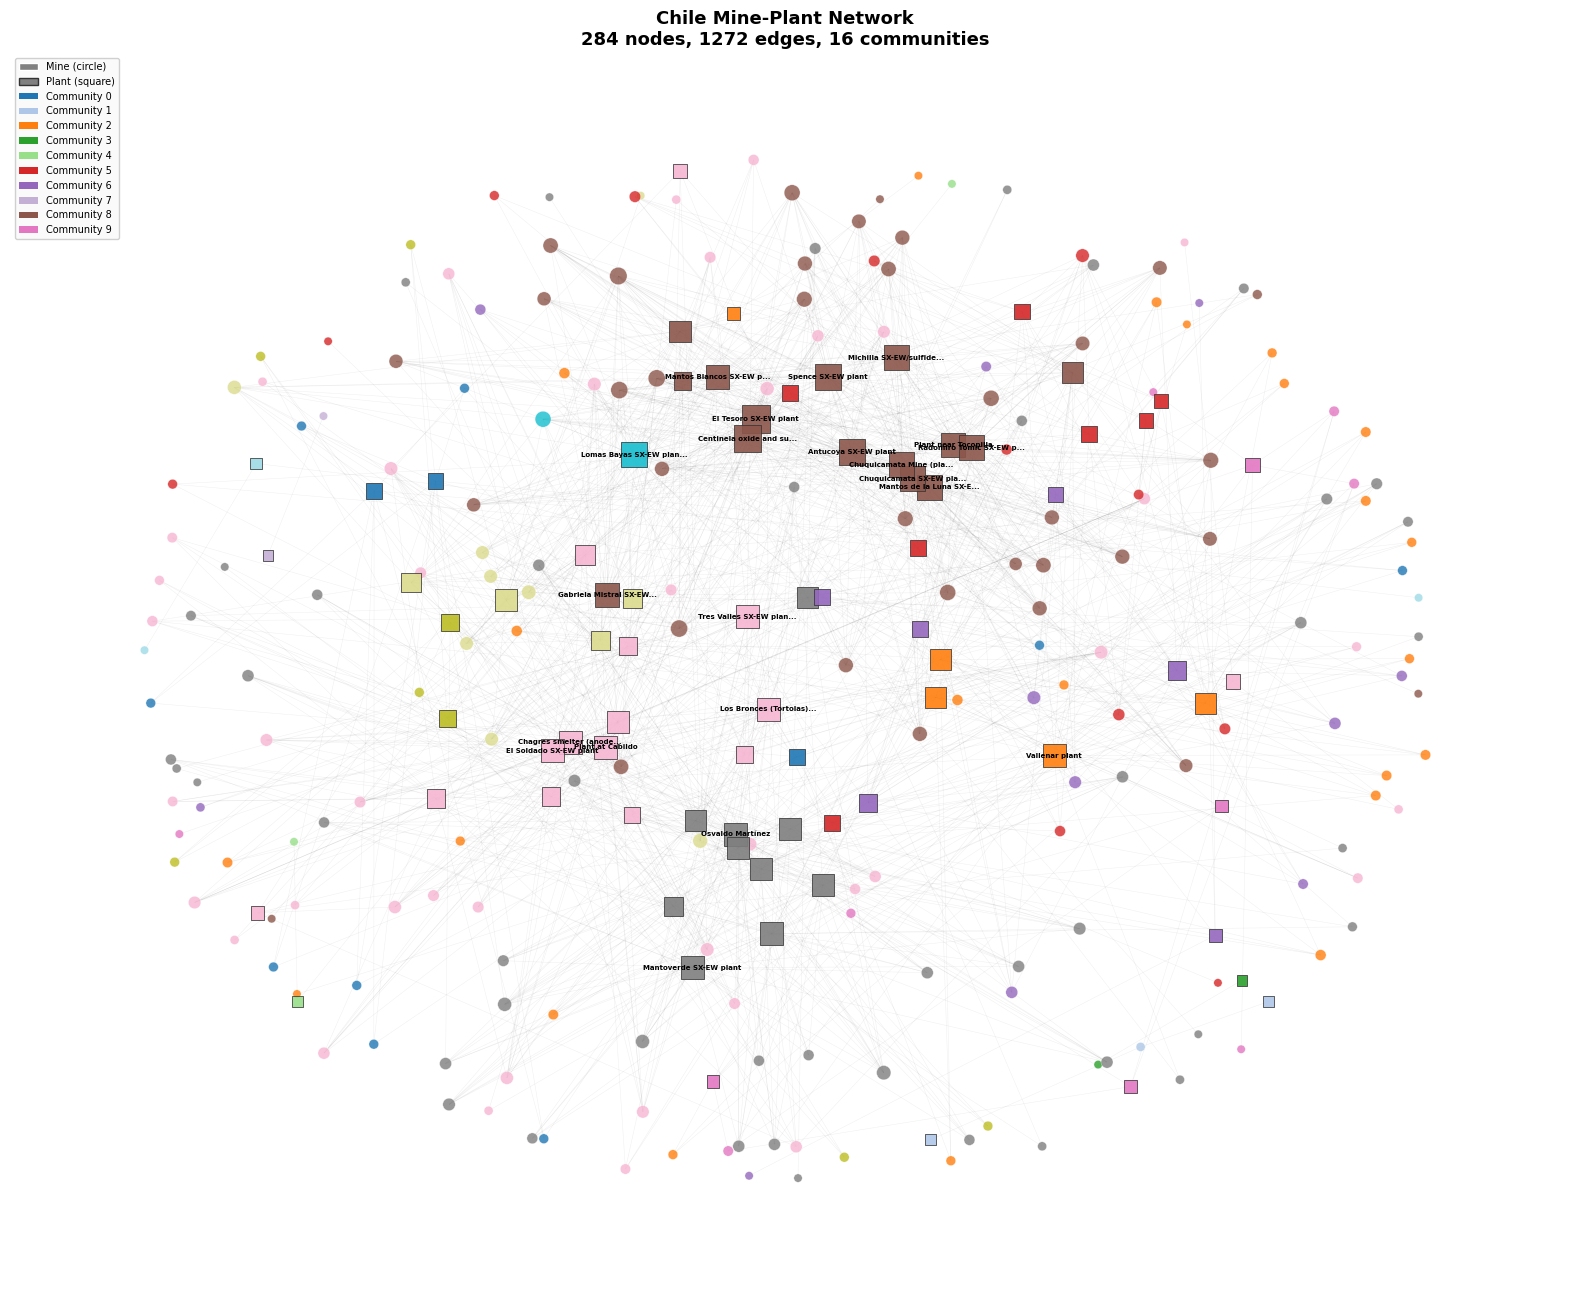

In [20]:
fig, ax = plt.subplots(figsize=(20, 16))
pos = nx.spring_layout(G, k=0.3, iterations=80, weight="weight", seed=42)

cmap = plt.cm.get_cmap("tab20", max(n_comms, 2))
max_deg = max(deg.values()) or 1
mine_list  = [n for n in G if G.nodes[n]["node_type"] == "mine"]
plant_list = [n for n in G if G.nodes[n]["node_type"] == "plant"]

nx.draw_networkx_edges(G, pos, alpha=0.06, width=0.4, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=mine_list,
                       node_color=[cmap(partition[n]) for n in mine_list],
                       node_size=[30 + 250 * (deg[n] / max_deg) for n in mine_list],
                       node_shape="o", alpha=0.8, ax=ax, edgecolors="white", linewidths=0.3)
nx.draw_networkx_nodes(G, pos, nodelist=plant_list,
                       node_color=[cmap(partition[n]) for n in plant_list],
                       node_size=[50 + 350 * (deg[n] / max_deg) for n in plant_list],
                       node_shape="s", alpha=0.9, ax=ax, edgecolors="#333", linewidths=0.6)

deg_thresh = sorted(deg.values(), reverse=True)[min(20, len(deg) - 1)]
labels = {n: (n[:22] + "..." if len(n) > 22 else n) for n in G if deg[n] >= deg_thresh}
nx.draw_networkx_labels(G, pos, labels, font_size=5, font_weight="bold", ax=ax)

handles = [mpatches.Patch(facecolor="gray", edgecolor="white", label="Mine (circle)"),
           mpatches.Patch(facecolor="gray", edgecolor="#333", label="Plant (square)")]
for i in range(min(n_comms, 10)):
    handles.append(mpatches.Patch(facecolor=cmap(i), label=f"Community {i}"))
ax.legend(handles=handles, loc="upper left", fontsize=7, framealpha=0.9)
ax.set_title(f"Chile Mine-Plant Network\n{G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
             f"{n_comms} communities", fontsize=13, fontweight="bold")
ax.axis("off")

fig.savefig(os.path.join(DIR_OUT, "Chile_Mine_Plant_Network.png"), dpi=200, bbox_inches="tight", facecolor="white")
plt.show(); plt.close()

## 16. Centrality distributions

Top row: histograms of degree, betweenness, and eigenvector centrality split by node type. Bottom row: the 15 highest-ranked nodes for each measure.

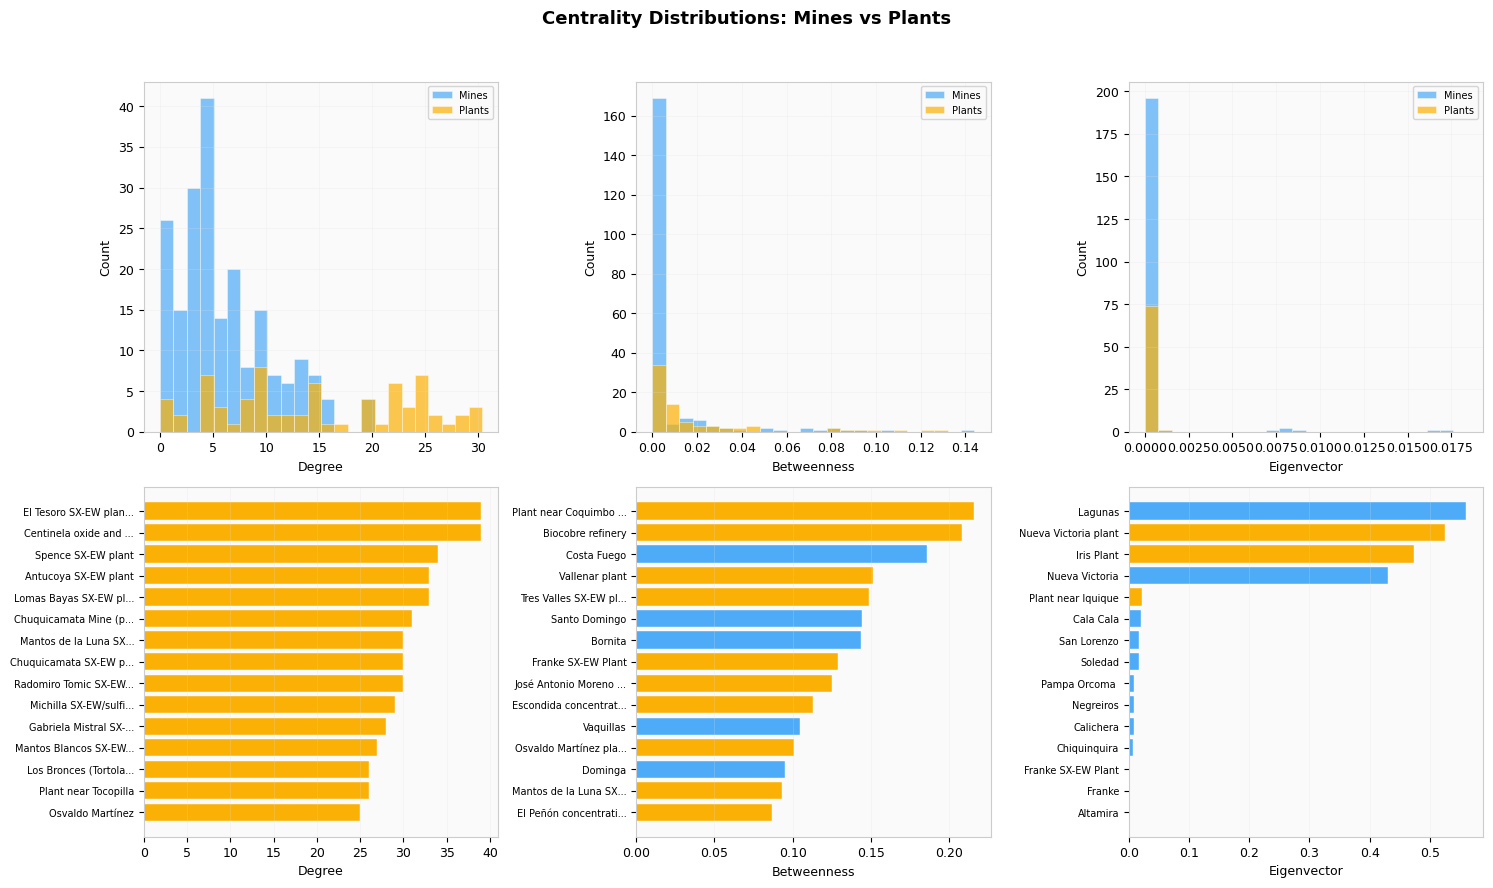

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
measures = [("DEGREE", "Degree"), ("BETWEENNESS_CENTRALITY", "Betweenness"),
            ("EIGENVECTOR_CENTRALITY", "Eigenvector")]
mine_m  = metrics[metrics.NODE_TYPE == "mine"]
plant_m = metrics[metrics.NODE_TYPE == "plant"]

for ci, (col, label) in enumerate(measures):
    ax = axes[0, ci]
    bins = np.linspace(0, metrics[col].quantile(0.98), 25)
    ax.hist(mine_m[col], bins=bins, alpha=0.7, color="#4dabf7", label="Mines", edgecolor="white", linewidth=0.4)
    ax.hist(plant_m[col], bins=bins, alpha=0.7, color="#fab005", label="Plants", edgecolor="white", linewidth=0.4)
    ax.set_xlabel(label); ax.set_ylabel("Count"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = axes[1, ci]
    top = metrics.nlargest(15, col)
    colors = ["#4dabf7" if t == "mine" else "#fab005" for t in top["NODE_TYPE"]]
    names = [n[:20] + "..." if len(n) > 20 else n for n in top["NODE"]]
    ax.barh(range(len(top)), top[col].values, color=colors, edgecolor="white", linewidth=0.3)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(names, fontsize=7)
    ax.invert_yaxis(); ax.set_xlabel(label); ax.grid(True, axis="x", alpha=0.3)

fig.suptitle("Centrality Distributions: Mines vs Plants", fontsize=13, fontweight="bold", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(os.path.join(DIR_OUT, "Chile_Network_Centrality.png"), dpi=200, bbox_inches="tight")
plt.show(); plt.close()

## 17. Community structure

Three panels: (a) stacked bar chart of community sizes by node type, (b) commodity composition within each community, (c) geographic scatter of all facilities coloured by community.

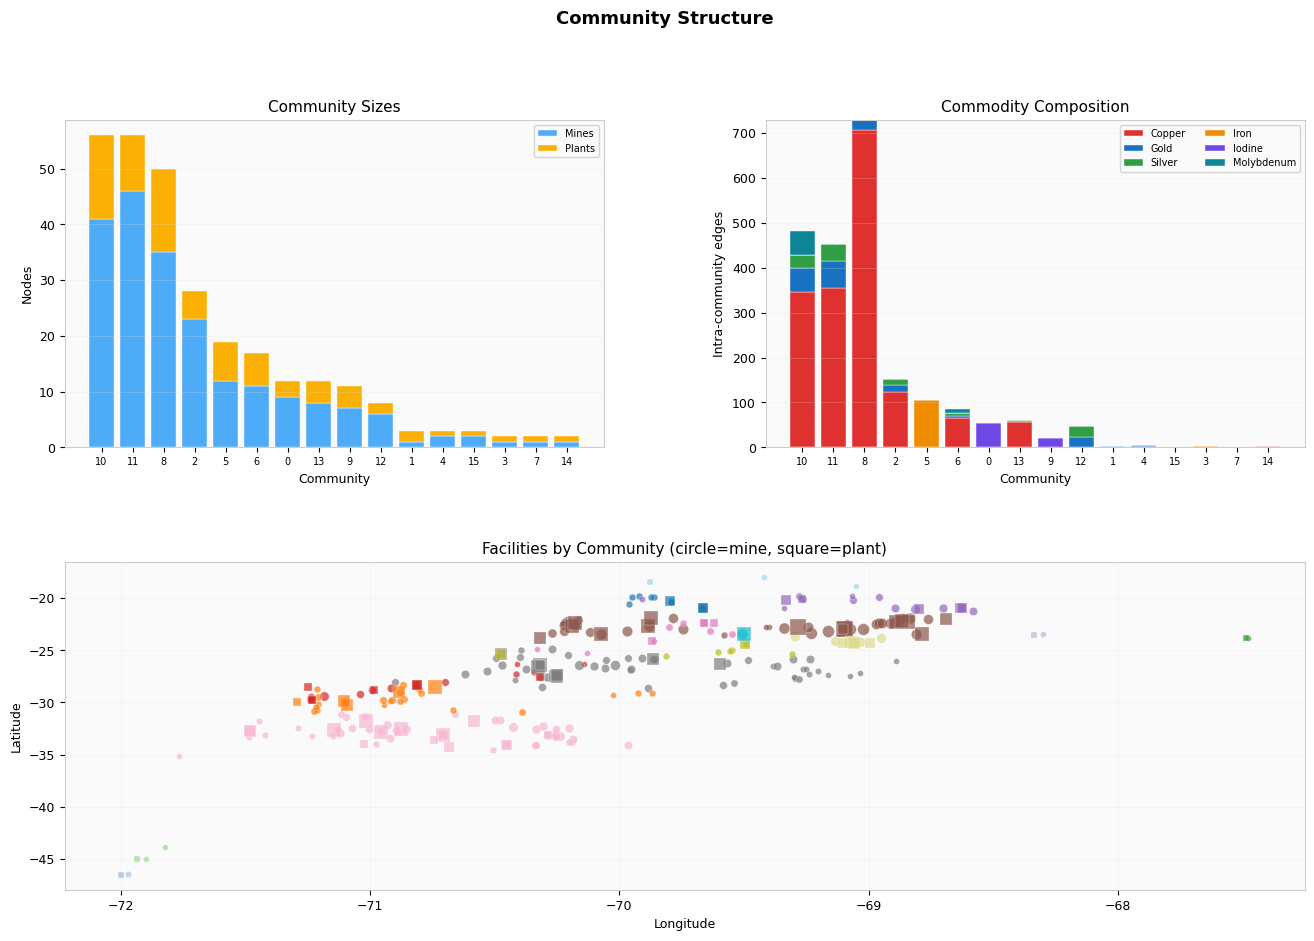

In [22]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

comm_ids = sorted(set(partition.values()),
                  key=lambda ci: -sum(1 for v in partition.values() if v == ci))
x = range(len(comm_ids))

# Panel 1: sizes
ax1 = fig.add_subplot(gs[0, 0])
mc = [sum(1 for n, ci in partition.items() if ci == cid and G.nodes[n]["node_type"] == "mine") for cid in comm_ids]
pc = [sum(1 for n, ci in partition.items() if ci == cid and G.nodes[n]["node_type"] == "plant") for cid in comm_ids]
ax1.bar(x, mc, color="#4dabf7", label="Mines", edgecolor="white", linewidth=0.3)
ax1.bar(x, pc, bottom=mc, color="#fab005", label="Plants", edgecolor="white", linewidth=0.3)
ax1.set_xticks(x); ax1.set_xticklabels([str(c) for c in comm_ids], fontsize=7)
ax1.set_xlabel("Community"); ax1.set_ylabel("Nodes"); ax1.set_title("Community Sizes")
ax1.legend(fontsize=7); ax1.grid(True, axis="y", alpha=0.3)

# Panel 2: commodity composition
ax2 = fig.add_subplot(gs[0, 1])
comm_comm = {}
for cid in comm_ids:
    members = [n for n, ci in partition.items() if ci == cid]
    cnt = Counter()
    for m in members:
        for nb in G.neighbors(m):
            if partition.get(nb) == cid:
                for tok in G.edges[m, nb].get("commodities", "").split(", "):
                    if tok.strip():
                        cnt[tok.strip()] += 1
    comm_comm[cid] = cnt

all_c = Counter()
for v in comm_comm.values():
    all_c.update(v)
top6 = [c for c, _ in all_c.most_common(6)]
tc = dict(zip(top6, ["#e03131", "#1971c2", "#2f9e44", "#f08c00", "#7048e8", "#0c8599"]))
bottom = np.zeros(len(comm_ids))
for commodity in top6:
    vals = [comm_comm[cid].get(commodity, 0) for cid in comm_ids]
    ax2.bar(x, vals, bottom=bottom, label=commodity, color=tc[commodity], edgecolor="white", linewidth=0.3)
    bottom += np.array(vals)
ax2.set_xticks(x); ax2.set_xticklabels([str(c) for c in comm_ids], fontsize=7)
ax2.set_xlabel("Community"); ax2.set_ylabel("Intra-community edges")
ax2.set_title("Commodity Composition"); ax2.legend(fontsize=7, ncol=2); ax2.grid(True, axis="y", alpha=0.3)

# Panel 3: geographic scatter
ax3 = fig.add_subplot(gs[1, :])
cmap_geo = plt.cm.get_cmap("tab20", max(partition.values()) + 1)
for node in G:
    nd = G.nodes[node]
    lat, lon = nd.get("lat"), nd.get("lon")
    if lat is None or lon is None or np.isnan(lat) or np.isnan(lon):
        continue
    ax3.scatter(lon, lat, c=[cmap_geo(partition[node])],
                s=15 + 3 * G.degree(node),
                marker="o" if nd["node_type"] == "mine" else "s",
                alpha=0.7, edgecolors="white", linewidths=0.3, zorder=2)
ax3.set_xlabel("Longitude"); ax3.set_ylabel("Latitude")
ax3.set_title("Facilities by Community (circle=mine, square=plant)")
ax3.grid(True, alpha=0.3)

fig.suptitle("Community Structure", fontsize=13, fontweight="bold", y=0.99)
fig.savefig(os.path.join(DIR_OUT, "Chile_Network_Communities.png"), dpi=200, bbox_inches="tight")
plt.show(); plt.close()

## 18. Commodity subnetwork comparison

Horizontal bar charts comparing subnetwork size, density, and average mine-to-plant distance across commodities with at least two edges.

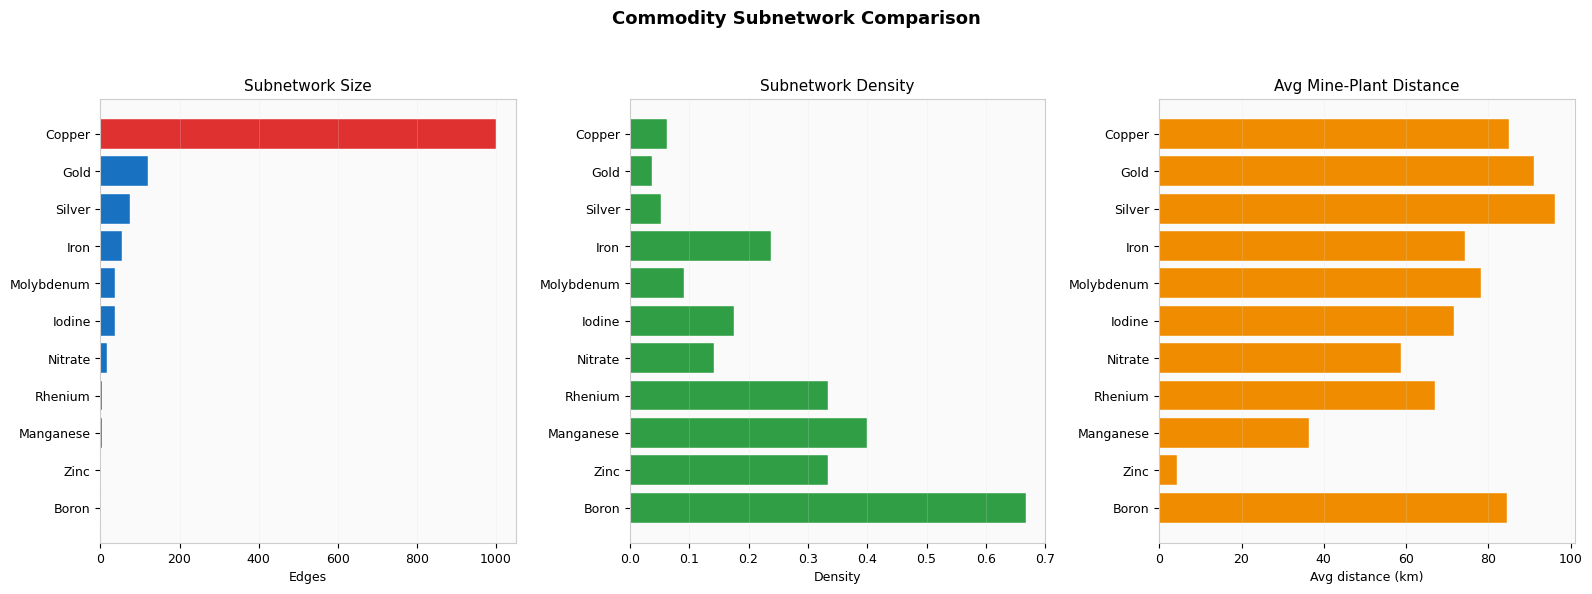

In [23]:
df_plot = sub_df[sub_df["N_EDGES"] >= 2].sort_values("N_EDGES", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

colors = ["#e03131" if c == "Copper" else "#1971c2" for c in df_plot["COMMODITY"]]
axes[0].barh(df_plot["COMMODITY"], df_plot["N_EDGES"], color=colors, edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Edges"); axes[0].set_title("Subnetwork Size"); axes[0].grid(True, axis="x", alpha=0.3)

axes[1].barh(df_plot["COMMODITY"], df_plot["DENSITY"], color="#2f9e44", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Density"); axes[1].set_title("Subnetwork Density"); axes[1].grid(True, axis="x", alpha=0.3)

axes[2].barh(df_plot["COMMODITY"], df_plot["AVG_DISTANCE_KM"], color="#f08c00", edgecolor="white", linewidth=0.3)
axes[2].set_xlabel("Avg distance (km)"); axes[2].set_title("Avg Mine-Plant Distance"); axes[2].grid(True, axis="x", alpha=0.3)

fig.suptitle("Commodity Subnetwork Comparison", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(os.path.join(DIR_OUT, "Chile_Network_Commodity_Comparison.png"), dpi=200, bbox_inches="tight")
plt.show(); plt.close()

## 19. Projected network degree distributions

Degree distributions of the mine-mine and plant-plant unipartite projections, with mean and median markers.

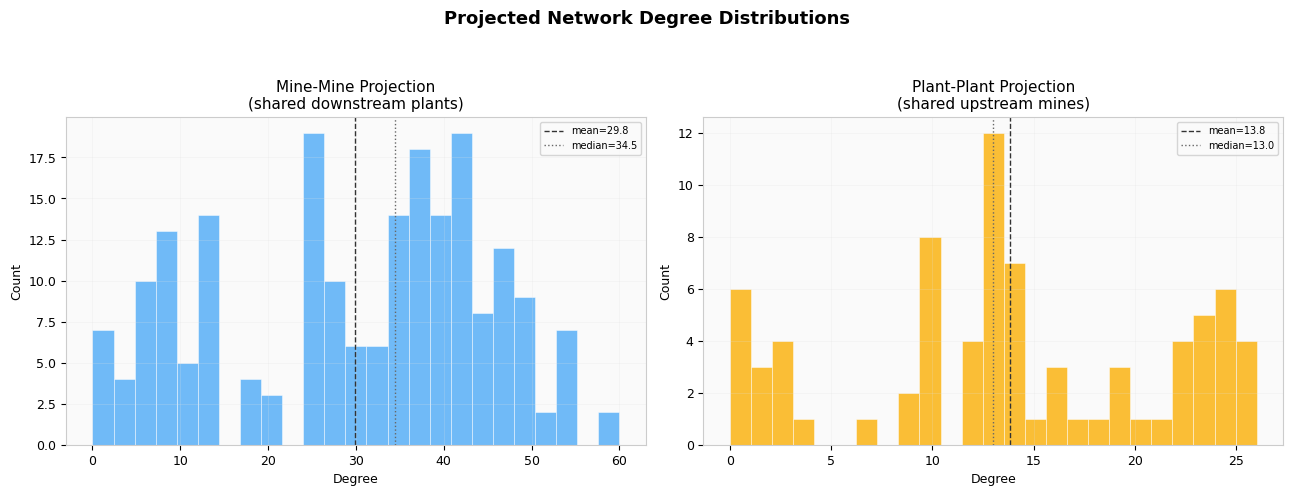

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, proj, title, color in [
    (axes[0], mine_proj, "Mine-Mine Projection\n(shared downstream plants)", "#4dabf7"),
    (axes[1], plant_proj, "Plant-Plant Projection\n(shared upstream mines)", "#fab005"),
]:
    if proj.number_of_edges() == 0:
        ax.text(0.5, 0.5, "No edges", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title); continue
    degs = [d for _, d in proj.degree()]
    ax.hist(degs, bins=25, color=color, edgecolor="white", linewidth=0.4, alpha=0.8)
    ax.axvline(np.mean(degs), color="#333", ls="--", lw=1, label=f"mean={np.mean(degs):.1f}")
    ax.axvline(np.median(degs), color="#666", ls=":", lw=1, label=f"median={np.median(degs):.1f}")
    ax.set_xlabel("Degree"); ax.set_ylabel("Count"); ax.set_title(title)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

fig.suptitle("Projected Network Degree Distributions", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(os.path.join(DIR_OUT, "Chile_Network_Projections.png"), dpi=200, bbox_inches="tight")
plt.show(); plt.close()

## 20. Interactive D3 force-directed network

Generates a self-contained HTML file with D3.js force-directed layout, commodity filter, colour-by, and size-by controls, and click-to-inspect node details.

In [25]:
# Prepare JSON payloads (reuse already-computed centrality)
nodes_json = [{
    "id": n, "type": G.nodes[n]["node_type"],
    "facility_type": G.nodes[n].get("facility_type", ""),
    "status": str(G.nodes[n].get("status", "")),
    "region": str(G.nodes[n].get("region", "")),
    "operator": str(G.nodes[n].get("operator", "")),
    "degree": deg[n],
    "betweenness": round(betw[n], 4),
    "community": partition.get(n, 0),
} for n in G.nodes()]

edges_json = [{
    "source": u, "target": v,
    "commodities": d.get("commodities", ""),
    "distance_km": round(d.get("distance_km", 0), 1),
} for u, v, d in G.edges(data=True)]

n_mines_g  = len(mine_nodes)
n_plants_g = len(plant_nodes)
n_comp_g   = nx.number_connected_components(G)
commodity_opts = "\n".join(f'            <option value="{c}">{c}</option>' for c in all_commodities)

# Build HTML via template substitution to avoid f-string brace conflicts with CSS/JS
HTML_TPL = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Chile Mine-Plant Network</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/d3/7.8.5/d3.min.js"></script>
<style>
  @import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Sans:wght@300;400;600&family=IBM+Plex+Mono:wght@400&display=swap');
  * { margin:0; padding:0; box-sizing:border-box; }
  body { font-family:'IBM Plex Sans',sans-serif; background:#0f1318; color:#c9d1d9; overflow:hidden; }
  #container { display:flex; height:100vh; }
  #sidebar { width:300px; min-width:300px; background:#161b22; border-right:1px solid #30363d; overflow-y:auto; padding:16px; }
  #sidebar h1 { font-size:15px; font-weight:600; color:#e6edf3; margin-bottom:2px; }
  #sidebar .sub { font-size:11px; color:#8b949e; margin-bottom:16px; }
  .ctrl { margin-bottom:12px; }
  .ctrl label { display:block; font-size:10px; font-weight:600; color:#8b949e; text-transform:uppercase; letter-spacing:0.4px; margin-bottom:4px; }
  select { width:100%; background:#0d1117; border:1px solid #30363d; color:#c9d1d9; padding:5px 6px; border-radius:3px; font-size:12px; font-family:inherit; }
  .stats { display:grid; grid-template-columns:1fr 1fr; gap:6px; margin-bottom:14px; }
  .sbox { background:#0d1117; border:1px solid #30363d; border-radius:3px; padding:8px; }
  .sbox .v { font-size:18px; font-weight:600; color:#e6edf3; }
  .sbox .l { font-size:10px; color:#8b949e; }
  #info { background:#0d1117; border:1px solid #30363d; border-radius:3px; padding:10px; font-size:11px; min-height:60px; margin-top:10px; }
  #info h3 { font-size:12px; color:#e6edf3; margin-bottom:4px; }
  #info .row { color:#8b949e; margin-bottom:2px; }
  #info .row span { color:#c9d1d9; }
  #graph { flex:1; position:relative; }
  svg { width:100%; height:100%; }
  .link { stroke:#30363d; stroke-opacity:0.3; }
  .link.highlighted { stroke:#58a6ff; stroke-opacity:0.8; stroke-width:1.5px; }
  .node { cursor:pointer; }
  .node text { font-family:'IBM Plex Mono',monospace; font-size:8px; fill:#8b949e; pointer-events:none; }
  .node.dimmed circle, .node.dimmed rect { opacity:0.1; }
  .node.dimmed text { opacity:0.05; }
  .link.dimmed { stroke-opacity:0.03; }
</style>
</head>
<body>
<div id="container">
  <div id="sidebar">
    <h1>Chile Mine-Plant Network</h1>
    <p class="sub">__NNODES__ nodes, __NEDGES__ edges</p>
    <div class="stats">
      <div class="sbox"><div class="v">__NMINES__</div><div class="l">Mines</div></div>
      <div class="sbox"><div class="v">__NPLANTS__</div><div class="l">Plants</div></div>
      <div class="sbox"><div class="v">__NCOMMS__</div><div class="l">Communities</div></div>
      <div class="sbox"><div class="v">__NCOMP__</div><div class="l">Components</div></div>
    </div>
    <div class="ctrl"><label>Filter by commodity</label>
      <select id="commFilter"><option value="all">All commodities</option>
__COMMODITY_OPTS__
      </select></div>
    <div class="ctrl"><label>Color by</label>
      <select id="colorBy"><option value="community">Community</option><option value="type">Node type</option><option value="degree">Degree</option></select></div>
    <div class="ctrl"><label>Size by</label>
      <select id="sizeBy"><option value="degree">Degree</option><option value="betweenness">Betweenness</option><option value="uniform">Uniform</option></select></div>
    <div id="info"><h3>Click a node for details</h3></div>
  </div>
  <div id="graph"></div>
</div>
<script>
const nodes=__NODES_JSON__;
const edges=__EDGES_JSON__;
const nComms=__NCOMMS__;
const width=document.getElementById("graph").clientWidth;
const height=document.getElementById("graph").clientHeight;
const svg=d3.select("#graph").append("svg").attr("viewBox",[0,0,width,height]);
const g=svg.append("g");
svg.call(d3.zoom().scaleExtent([0.1,8]).on("zoom",e=>g.attr("transform",e.transform)));
const commColors=d3.scaleOrdinal(d3.schemeTableau10).domain(d3.range(nComms));
const typeColors={"mine":"#4dabf7","plant":"#fab005"};
const maxDeg=d3.max(nodes,d=>d.degree)||1;
const maxBetw=d3.max(nodes,d=>d.betweenness)||0.001;
const sim=d3.forceSimulation(nodes)
  .force("link",d3.forceLink(edges).id(d=>d.id).distance(d=>30+d.distance_km*0.3).strength(0.15))
  .force("charge",d3.forceManyBody().strength(-40))
  .force("center",d3.forceCenter(width/2,height/2))
  .force("collision",d3.forceCollide().radius(d=>nr(d)+2));
const link=g.append("g").selectAll("line").data(edges).join("line").attr("class","link").attr("stroke-width",0.6);
const node=g.append("g").selectAll("g").data(nodes).join("g").attr("class","node")
  .call(d3.drag().on("start",(e,d)=>{if(!e.active)sim.alphaTarget(0.3).restart();d.fx=d.x;d.fy=d.y;})
  .on("drag",(e,d)=>{d.fx=e.x;d.fy=e.y;}).on("end",(e,d)=>{if(!e.active)sim.alphaTarget(0);d.fx=null;d.fy=null;}));
node.each(function(d){const el=d3.select(this);if(d.type==="mine"){el.append("circle").attr("r",nr(d)).attr("fill",gc(d)).attr("stroke","#fff").attr("stroke-width",0.4);}else{const r=nr(d);el.append("rect").attr("x",-r).attr("y",-r).attr("width",r*2).attr("height",r*2).attr("rx",2).attr("fill",gc(d)).attr("stroke","#333").attr("stroke-width",0.5);}});
node.filter(d=>d.degree>=d3.quantile(nodes.map(n=>n.degree).sort(d3.ascending),0.85))
  .append("text").text(d=>d.id.length>20?d.id.slice(0,18)+"...":d.id).attr("dx",d=>nr(d)+3).attr("dy",3);
node.on("click",(e,d)=>{e.stopPropagation();showInfo(d);hl(d);});
svg.on("click",()=>{rhl();ci();});
sim.on("tick",()=>{link.attr("x1",d=>d.source.x).attr("y1",d=>d.source.y).attr("x2",d=>d.target.x).attr("y2",d=>d.target.y);node.attr("transform",d=>`translate(${d.x},${d.y})`);});
function nr(d){const s=document.getElementById("sizeBy").value;if(s==="uniform")return 5;if(s==="betweenness")return 3+15*Math.sqrt(d.betweenness/maxBetw);return 3+12*(d.degree/maxDeg);}
function gc(d){const c=document.getElementById("colorBy").value;if(c==="type")return typeColors[d.type]||"#999";if(c==="degree")return d3.interpolateYlOrRd(d.degree/maxDeg);return commColors(d.community);}
function uv(){node.select("circle").attr("r",d=>nr(d)).attr("fill",d=>gc(d));node.select("rect").each(function(d){const r=nr(d);d3.select(this).attr("x",-r).attr("y",-r).attr("width",r*2).attr("height",r*2).attr("fill",gc(d));});}
document.getElementById("commFilter").addEventListener("change",function(){const v=this.value;if(v==="all"){node.classed("dimmed",false);link.classed("dimmed",false);return;}const ae=new Set(),an=new Set();edges.forEach((e,i)=>{if(e.commodities.includes(v)){ae.add(i);an.add(typeof e.source==="object"?e.source.id:e.source);an.add(typeof e.target==="object"?e.target.id:e.target);}});node.classed("dimmed",d=>!an.has(d.id));link.classed("dimmed",(d,i)=>!ae.has(i));});
document.getElementById("colorBy").addEventListener("change",uv);
document.getElementById("sizeBy").addEventListener("change",uv);
function hl(d){const nb=new Set();edges.forEach(e=>{const s=typeof e.source==="object"?e.source.id:e.source,t=typeof e.target==="object"?e.target.id:e.target;if(s===d.id)nb.add(t);if(t===d.id)nb.add(s);});nb.add(d.id);node.classed("dimmed",n=>!nb.has(n.id));link.classed("dimmed",e=>{const s=typeof e.source==="object"?e.source.id:e.source,t=typeof e.target==="object"?e.target.id:e.target;return s!==d.id&&t!==d.id;});link.classed("highlighted",e=>{const s=typeof e.source==="object"?e.source.id:e.source,t=typeof e.target==="object"?e.target.id:e.target;return s===d.id||t===d.id;});}
function rhl(){node.classed("dimmed",false);link.classed("dimmed",false).classed("highlighted",false);}
function showInfo(d){const el=document.getElementById("info");let h=`<h3>${d.id}</h3><div class="row">Type: <span>${d.facility_type}</span></div><div class="row">Status: <span>${d.status}</span></div>`;if(d.region&&d.region!=="nan")h+=`<div class="row">Region: <span>${d.region}</span></div>`;if(d.operator&&d.operator!=="nan")h+=`<div class="row">Operator: <span>${d.operator}</span></div>`;h+=`<div class="row">Degree: <span>${d.degree}</span></div><div class="row">Betweenness: <span>${d.betweenness}</span></div><div class="row">Community: <span>${d.community}</span></div>`;const cn=[];edges.forEach(e=>{const s=typeof e.source==="object"?e.source.id:e.source,t=typeof e.target==="object"?e.target.id:e.target;if(s===d.id)cn.push({name:t,comm:e.commodities,dist:e.distance_km});if(t===d.id)cn.push({name:s,comm:e.commodities,dist:e.distance_km});});cn.sort((a,b)=>a.dist-b.dist);if(cn.length){h+=`<div class="row" style="margin-top:6px"><strong>Connected (${cn.length}):</strong></div>`;cn.slice(0,8).forEach(c=>{h+=`<div class="row">${c.name} <span style="color:#58a6ff">${c.dist}km</span> [${c.comm}]</div>`;});if(cn.length>8)h+=`<div class="row">... and ${cn.length-8} more</div>`;}el.innerHTML=h;}
function ci(){document.getElementById("info").innerHTML='<h3>Click a node for details</h3>';}
</script>
</body>
</html>"""

html_content = (HTML_TPL
    .replace("__NODES_JSON__", json.dumps(nodes_json))
    .replace("__EDGES_JSON__", json.dumps(edges_json))
    .replace("__NNODES__", str(G.number_of_nodes()))
    .replace("__NEDGES__", str(G.number_of_edges()))
    .replace("__NMINES__", str(n_mines_g))
    .replace("__NPLANTS__", str(n_plants_g))
    .replace("__NCOMMS__", str(n_comms))
    .replace("__NCOMP__", str(n_comp_g))
    .replace("__COMMODITY_OPTS__", commodity_opts))

path_html = os.path.join(DIR_HTML, "Chile_Mine_Plant_Network.html")
with open(path_html, "w", encoding="utf-8") as f:
    f.write(html_content)
print(f"Saved: {path_html}")

Saved: /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Interactive/Chile_Mine_Plant_Network.html


## 21. Geographic supply chain map (Folium)

Interactive Leaflet map with commodity-filtered layers. Mine markers are circles (blue), plant markers are rotated squares (amber). A static matplotlib version is saved separately for report use.

In [26]:
geo = links.dropna(subset=["MINE_LAT", "MINE_LON", "PLANT_LAT", "PLANT_LON"]).copy()
geo["PRIMARY_COMMODITY"] = geo["SHARED_COMMODITIES"].apply(
    lambda s: next((t.strip() for t in str(s).split(",") if t.strip()), "Unknown"))

center_lat = geo[["MINE_LAT", "PLANT_LAT"]].values.flatten().mean()
center_lon = geo[["MINE_LON", "PLANT_LON"]].values.flatten().mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles=None, control_scale=True)
folium.TileLayer("cartodbpositron", name="Light basemap").add_to(m)
folium.TileLayer("cartodbdark_matter", name="Dark basemap").add_to(m)

mine_deg  = geo.groupby("MINE_NAME").size().to_dict()
plant_deg = geo.groupby("PLANT_NAME").size().to_dict()
mines_g   = geo.drop_duplicates("MINE_NAME").set_index("MINE_NAME")
plants_g  = geo.drop_duplicates("PLANT_NAME").set_index("PLANT_NAME")
commodities_geo = sorted(geo["PRIMARY_COMMODITY"].unique())

# All links
fg_all = folium.FeatureGroup(name="All supply links", show=True)
for _, r in geo.iterrows():
    folium.PolyLine(
        [[r["MINE_LAT"], r["MINE_LON"]], [r["PLANT_LAT"], r["PLANT_LON"]]],
        color=commodity_color(r["PRIMARY_COMMODITY"]), weight=1.2, opacity=0.25,
        tooltip=f"{r['MINE_NAME']} > {r['PLANT_NAME']}<br>{r['SHARED_COMMODITIES']}<br>{r['DISTANCE_KM']:.1f} km",
    ).add_to(fg_all)
fg_all.add_to(m)

# Per-commodity layers
for comm in commodities_geo:
    sub = geo[geo["PRIMARY_COMMODITY"] == comm]
    if sub.empty:
        continue
    fg = folium.FeatureGroup(name=f"{comm} ({len(sub)})", show=False)
    col = commodity_color(comm)
    for _, r in sub.iterrows():
        folium.PolyLine(
            [[r["MINE_LAT"], r["MINE_LON"]], [r["PLANT_LAT"], r["PLANT_LON"]]],
            color=col, weight=2.0, opacity=0.6,
            tooltip=f"{r['MINE_NAME']} > {r['PLANT_NAME']}<br>{r['SHARED_COMMODITIES']}<br>{r['DISTANCE_KM']:.1f} km",
        ).add_to(fg)
    fg.add_to(m)

# Mine markers
fg_mines = folium.FeatureGroup(name="Mines", show=True)
for name, r in mines_g.iterrows():
    d = mine_deg.get(name, 1)
    comms = sorted({t.strip() for t in geo[geo["MINE_NAME"]==name]["SHARED_COMMODITIES"].str.cat(sep=", ").split(",") if t.strip()})
    folium.CircleMarker(
        [r["MINE_LAT"], r["MINE_LON"]], radius=3+min(d*0.8, 12),
        color="#2d3436", fill=True, fill_color="#4dabf7", fill_opacity=0.75, weight=0.6,
        popup=f"<b>{name}</b><br>Type: {r.get('MINE_TYPE','')}<br>Status: {r.get('MINE_STATUS','')}<br>"
              f"Region: {r.get('MINE_REGION','')}<br>Operator: {r.get('MINE_OPERATOR','')}<br>"
              f"Connections: {d}<br>Commodities: {', '.join(comms)}",
        tooltip=f"{name} (mine, deg={d})",
    ).add_to(fg_mines)
fg_mines.add_to(m)

# Plant markers
fg_plants = folium.FeatureGroup(name="Plants", show=True)
for name, r in plants_g.iterrows():
    d = plant_deg.get(name, 1)
    comms = sorted({t.strip() for t in geo[geo["PLANT_NAME"]==name]["SHARED_COMMODITIES"].str.cat(sep=", ").split(",") if t.strip()})
    popup = (f"<b>{name}</b><br>Type: {r.get('PLANT_TYPE','')}<br>Status: {r.get('PLANT_STATUS','')}<br>"
             f"Operator: {r.get('PLANT_OPERATOR','')}<br>Connections: {d}<br>Commodities: {', '.join(comms)}")
    cap = r.get("PLANT_CAPACITY")
    if pd.notna(cap):
        popup += f"<br>Capacity: {cap} {r.get('PLANT_CAPACITY_UNITS','')}"
    folium.RegularPolygonMarker(
        [r["PLANT_LAT"], r["PLANT_LON"]], number_of_sides=4, radius=4+min(d*0.8, 14),
        color="#2d3436", fill=True, fill_color="#fab005", fill_opacity=0.80, weight=0.6, rotation=45,
        popup=popup, tooltip=f"{name} (plant, deg={d})",
    ).add_to(fg_plants)
fg_plants.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# Legend
leg = '<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;padding:12px 16px;border-radius:6px;box-shadow:0 2px 8px rgba(0,0,0,0.2);font-size:12px;font-family:sans-serif;line-height:1.6;"><b>Legend</b><br>'
leg += '<span style="display:inline-block;width:12px;height:12px;border-radius:50%;background:#4dabf7;margin-right:6px;vertical-align:middle;border:1px solid #2d3436;"></span> Mine<br>'
leg += '<span style="display:inline-block;width:12px;height:12px;background:#fab005;margin-right:6px;vertical-align:middle;border:1px solid #2d3436;transform:rotate(45deg);"></span> Plant<br><hr style="margin:4px 0;">'
for cm in commodities_geo:
    leg += f'<span style="display:inline-block;width:20px;height:3px;background:{commodity_color(cm)};margin-right:6px;vertical-align:middle;"></span>{cm}<br>'
leg += '</div>'
m.get_root().html.add_child(folium.Element(leg))

path_map = os.path.join(DIR_HTML, "Chile_Supply_Chain_Map.html")
m.save(path_map)
print(f"Saved: {path_map}")

Saved: /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Interactive/Chile_Supply_Chain_Map.html


## 22. Static geographic map (for reports)

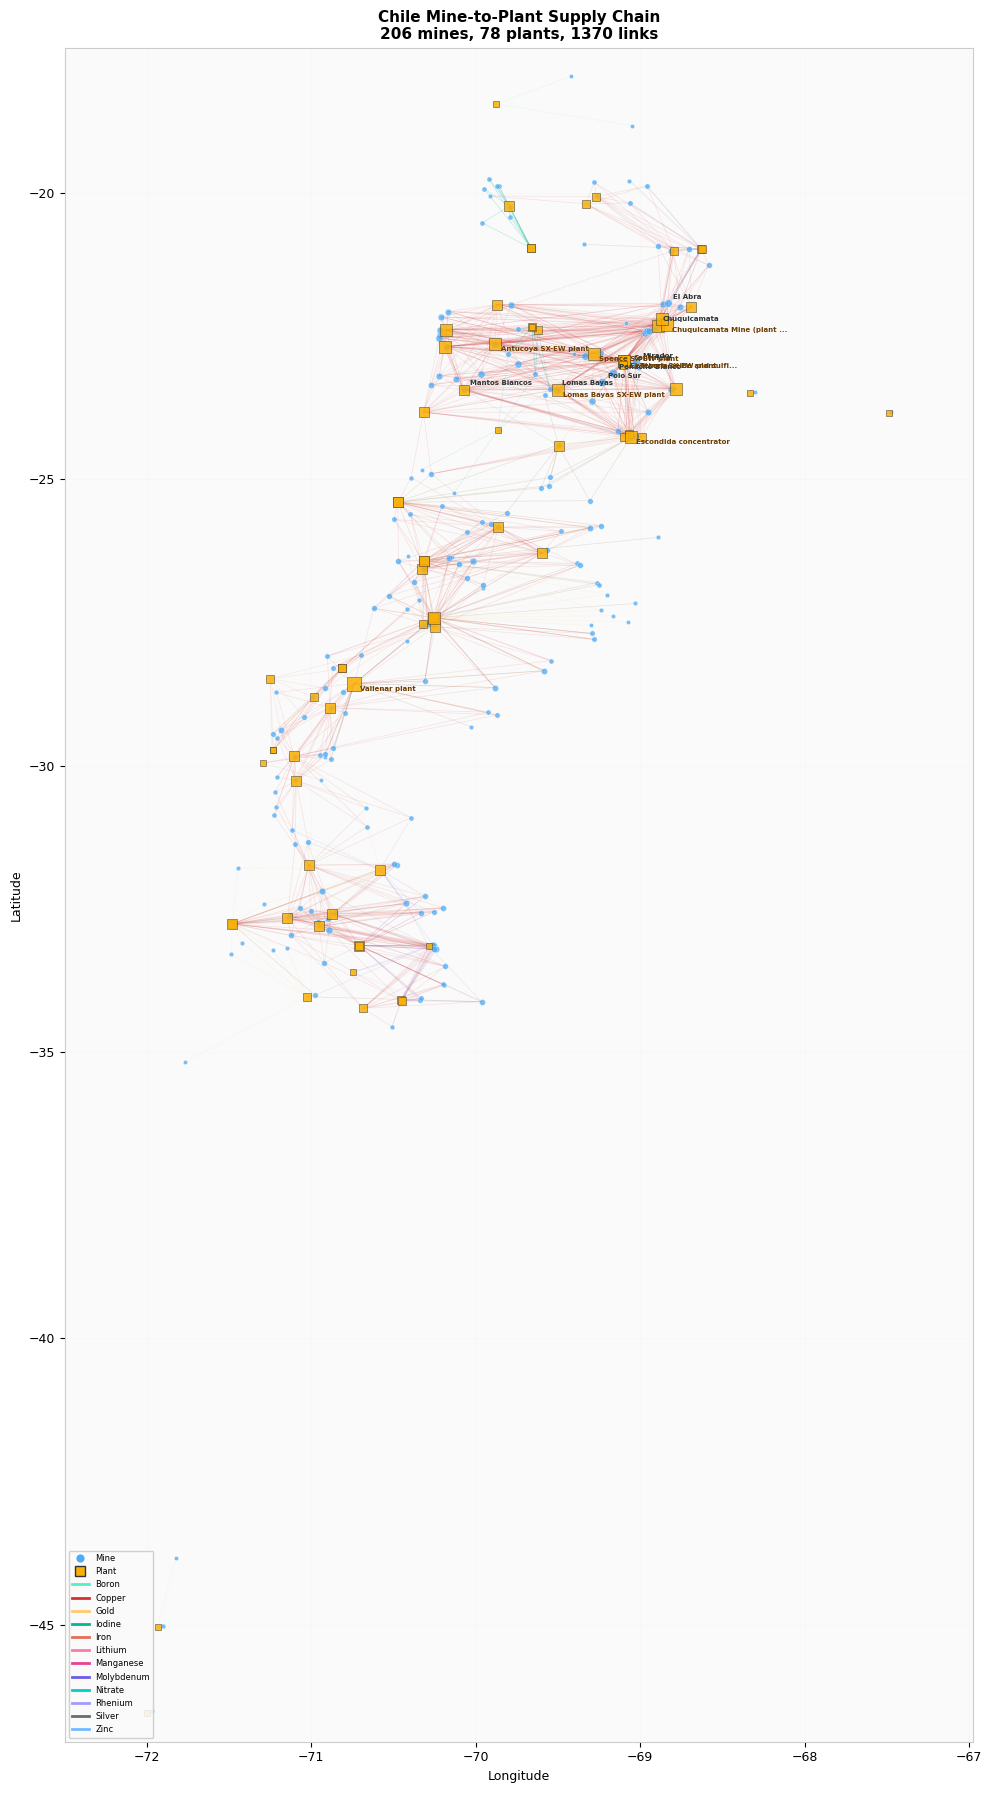

In [27]:
fig, ax = plt.subplots(figsize=(10, 18))
for _, r in geo.iterrows():
    ax.plot([r["MINE_LON"], r["PLANT_LON"]], [r["MINE_LAT"], r["PLANT_LAT"]],
            color=commodity_color(r["PRIMARY_COMMODITY"]), alpha=0.12, linewidth=0.5, zorder=1)

max_deg_geo = max(max(mine_deg.values()), max(plant_deg.values()))
for name, r in mines_g.iterrows():
    ax.scatter(r["MINE_LON"], r["MINE_LAT"], s=8+60*(mine_deg.get(name,1)/max_deg_geo),
               c="#4dabf7", marker="o", edgecolors="white", linewidths=0.3, alpha=0.75, zorder=3)
for name, r in plants_g.iterrows():
    ax.scatter(r["PLANT_LON"], r["PLANT_LAT"], s=12+80*(plant_deg.get(name,1)/max_deg_geo),
               c="#fab005", marker="s", edgecolors="#333", linewidths=0.4, alpha=0.85, zorder=4)

for names_list, df_idx, prefix, ofs, fc in [
    (sorted(mine_deg, key=mine_deg.get, reverse=True)[:8], mines_g, "MINE", (4,3), "#2d3436"),
    (sorted(plant_deg, key=plant_deg.get, reverse=True)[:8], plants_g, "PLANT", (4,-5), "#6c3c00"),
]:
    for name in names_list:
        if name in df_idx.index:
            r = df_idx.loc[name]
            ax.annotate(name[:25]+"..." if len(name)>25 else name,
                        (r[f"{prefix}_LON"], r[f"{prefix}_LAT"]),
                        fontsize=5, color=fc, fontweight="bold",
                        xytext=ofs, textcoords="offset points", zorder=5)

handles = [
    mlines.Line2D([],[],marker="o",color="w",markerfacecolor="#4dabf7",markeredgecolor="white",markersize=7,label="Mine"),
    mlines.Line2D([],[],marker="s",color="w",markerfacecolor="#fab005",markeredgecolor="#333",markersize=7,label="Plant"),
]
for cm in commodities_geo:
    handles.append(mlines.Line2D([],[],color=commodity_color(cm),linewidth=2,label=cm))
ax.legend(handles=handles, loc="lower left", fontsize=6, framealpha=0.9, edgecolor="#ccc")

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Chile Mine-to-Plant Supply Chain\n{geo['MINE_NAME'].nunique()} mines, "
             f"{geo['PLANT_NAME'].nunique()} plants, {len(geo)} links", fontsize=11, fontweight="bold")
ax.set_facecolor("#fafafa"); ax.grid(True, alpha=0.2, linewidth=0.4)
lons = pd.concat([geo["MINE_LON"], geo["PLANT_LON"]])
lats = pd.concat([geo["MINE_LAT"], geo["PLANT_LAT"]])
ax.set_xlim(lons.min()-0.5, lons.max()+0.5); ax.set_ylim(lats.min()-0.5, lats.max()+0.5)
fig.tight_layout()
fig.savefig(os.path.join(DIR_OUT, "Chile_Supply_Chain_Map.png"), dpi=200, bbox_inches="tight", facecolor="white")
plt.show(); plt.close()

## 23. Save summary outputs

Final deliverables:
- `Preliminary/Chile_Network_Metrics.csv`: per-node centrality metrics and community assignment.
- `Preliminary/Chile_Network_Summary.txt`: plain-text summary of graph statistics.

In [28]:
metrics.to_csv(os.path.join(DIR_PRELIM, "Chile_Network_Metrics.csv"), index=False)

summary_path = os.path.join(DIR_PRELIM, "Chile_Network_Summary.txt")
with open(summary_path, "w") as f:
    f.write("CHILE MINE-PLANT SUPPLY CHAIN NETWORK ANALYSIS\n")
    f.write("=" * 50 + "\n\n")

    f.write("BIPARTITE GRAPH\n")
    f.write(f"  Nodes: {G.number_of_nodes()} ({len(mine_nodes)} mines, {len(plant_nodes)} plants)\n")
    f.write(f"  Edges: {G.number_of_edges()}\n")
    f.write(f"  Density: {nx.density(G):.4f}\n")
    f.write(f"  Connected components: {nx.number_connected_components(G)}\n")
    f.write(f"  Largest component: {len(lcc)} nodes ({len(lcc)/G.number_of_nodes()*100:.1f}%)\n\n")

    f.write("COMMUNITY DETECTION (Louvain)\n")
    f.write(f"  Communities: {n_comms}\n")
    f.write(f"  Modularity: {modularity:.4f}\n\n")

    f.write("MINE-MINE PROJECTION (shared plants)\n")
    f.write(f"  Nodes: {mine_proj.number_of_nodes()}, Edges: {mine_proj.number_of_edges()}\n")
    f.write(f"  Density: {nx.density(mine_proj):.4f}\n")
    if mine_proj.number_of_edges() > 0:
        f.write(f"  Avg clustering: {nx.average_clustering(mine_proj, weight='weight'):.4f}\n")

    f.write("\nPLANT-PLANT PROJECTION (shared mines)\n")
    f.write(f"  Nodes: {plant_proj.number_of_nodes()}, Edges: {plant_proj.number_of_edges()}\n")
    f.write(f"  Density: {nx.density(plant_proj):.4f}\n")
    if plant_proj.number_of_edges() > 0:
        f.write(f"  Avg clustering: {nx.average_clustering(plant_proj, weight='weight'):.4f}\n")

    f.write("\nCOMMODITY SUBNETWORKS\n")
    f.write(sub_df.to_string(index=False))
    f.write("\n")

elapsed = time.time() - start_time
print(f"Done in {elapsed:.1f}s")
print(f"\nOutputs:     {DIR_OUT}")
print(f"Interactive: {DIR_HTML}")
print(f"Preliminary: {DIR_PRELIM}")

Done in 24.8s

Outputs:     /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Outputs
Interactive: /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Interactive
Preliminary: /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Preliminary
